In [ ]:
import polars as pl
# Lê apenas a primeira linha para ver o "cabeçalho"
schema = pl.read_parquet("statsbomb_completo.parquet", n_rows=1).columns
print("📋 Colunas reais do arquivo:", schema)

In [15]:
import polars as pl
import numpy as np
import os

os.makedirs("Data/atacks_defense", exist_ok=True)

# 1. NOMES REAIS NO DISCO (Com pontos, como o StatsBomb gera no Parquet)
# Se der erro em algum desses, o print abaixo vai te mostrar o nome correto
cols_disco = [
    "match_id", "index", "type.name", "location", "player.name", 
    "under_pressure", "play_pattern.name", "pass.type.name"
]

print("⚡ Carregando colunas originais...")

try:
    df = pl.read_parquet(
        "statsbomb_completo.parquet", 
        n_rows=1000000, 
        columns=cols_disco
    )
    
    # 2. RENOMEAR IMEDIATAMENTE (Trocando '.' por '_')
    # Isso garante que o resto do seu código (x, y, geometria) continue funcionando
    df = df.rename({col: col.replace(".", "_") for col in df.columns}).sort(["match_id", "index"])
    
    print("✅ Colunas mapeadas e renomeadas com sucesso!")

except pl.ColumnNotFoundError as e:
    print(f"❌ Erro de coluna! O Polars não achou uma das colunas da lista.")
    # Script de emergência para você ver os nomes reais se falhar:
    real_cols = pl.read_parquet("statsbomb_completo.parquet", n_rows=1).columns
    print(f"📋 Colunas que REALMENTE existem no seu arquivo:\n{real_cols}")
    raise e

# ---------------------------------------------------------
# 3. SEGUE O SEU CÓDIGO DE GEOMETRIA (Igual ao anterior)
# ---------------------------------------------------------
df = df.with_columns([
    pl.col("location").list.get(0).fill_null(120.0).alias("x"),
    pl.col("location").list.get(1).fill_null(40.0).alias("y"),
    pl.col("under_pressure").fill_null(False).cast(pl.Int8).alias("pressao_binaria")
])

x_arr, y_arr = df["x"].to_numpy(), df["y"].to_numpy()
dist = np.sqrt((120 - x_arr)**2 + (40 - y_arr)**2)

# Lei dos Cossenos para o ângulo de visão
a = np.sqrt((120 - x_arr)**2 + (36 - y_arr)**2)
b = np.sqrt((120 - x_arr)**2 + (44 - y_arr)**2)
cos_theta = np.clip((a**2 + b**2 - 8**2) / (2 * a * b), -1.0, 1.0)
angulo = np.degrees(np.arccos(cos_theta))

# 3. FEATURES DE CONTEXTO (Escanteio + Volume de Pressão)
df_contexto = df.with_columns([
    pl.Series("distancia", dist),
    pl.Series("angulo_visao", angulo),
    # Pressão nos últimos 10 lances (vibe defensiva)
    pl.col("pressao_binaria").rolling_mean(window_size=10, min_samples=1).over("match_id").alias("pressao_10_lances"),
    # Aceleração do ataque
    (pl.col("x") - pl.col("x").shift(5).over("match_id")).alias("aceleracao_ataque"),
    # Progresso do último lance
    (pl.col("x") - pl.col("x").shift(1).over("match_id")).alias("progresso_ultimo_lance"),
    
    # --- NOVAS FEATURES ---
    # É escanteio? (Padrão de jogo ou tipo de passe)
    ((pl.col("play_pattern_name") == "From Corner") | 
     (pl.col("pass_type_name") == "Corner")).cast(pl.Int8).alias("contexto_escanteio"),
    
    # Volume de Ataque Perigoso: Quantas vezes o time entrou nos últimos 20m (x > 100) nos últimos 50 eventos
    (pl.col("x") > 100).cast(pl.Int8).rolling_sum(window_size=50, min_samples=1).over("match_id").alias("volume_ataque_perigoso")
])

# 4. TARGET: Iminência (Janela de 10 eventos)
df_total = df_contexto.with_columns([
    (pl.col("type_name") == "Shot").cast(pl.Int8).alias("eh_chute")
]).with_columns([
    pl.col("eh_chute")
      .shift(-10)
      .rolling_max(window_size=10, min_samples=1)
      .over("match_id")
      .fill_null(0)
      .alias("iminencia_gol")
])

# 5. O SPLIT ESTRATÉGICO
features_treino = [
    "match_id", "player_name", "x", "y", "distancia", 
    "angulo_visao", "pressao_10_lances", "aceleracao_ataque", 
    "progresso_ultimo_lance", "contexto_escanteio", "volume_ataque_perigoso", "iminencia_gol"
]

df_ataque = df_total.filter(
    pl.col("type_name").is_in(["Pass", "Carry", "Dribble", "Ball Recovery"])
).select(features_treino).fill_null(0)

df_defesa = df_total.select([
    "match_id", "index", "player_name", "type_name", "x", "y"
] + [c for c in df_total.columns if "goalkeeper" in c or "block" in c or "foul" in c])

# 6. SALVANDO
df_ataque.write_parquet("Data/atacks_defense/ataque_oraculo.parquet")
df_defesa.write_parquet("Data/atacks_defense/defesa_lookup.parquet")

print("-" * 30)
print(f"✅ DATASET ATAQUE PRONTO: {df_ataque.height:,} linhas")
print(f"🎯 Novas Features: contexto_escanteio, volume_ataque_perigoso")
print("-" * 30)

⚡ Carregando colunas originais...
✅ Colunas mapeadas e renomeadas com sucesso!
------------------------------
✅ DATASET ATAQUE PRONTO: 543,005 linhas
🎯 Novas Features: contexto_escanteio, volume_ataque_perigoso
------------------------------


🚀 Iniciando PIPELINE PROFISSIONAL (Híbrido Micro+Macro)...
🔄 Validando Oráculo em 289 partidas...
Fold 1 → AUC: 0.7804
Fold 2 → AUC: 0.7916
Fold 3 → AUC: 0.7892
Fold 4 → AUC: 0.7876
Fold 5 → AUC: 0.7725

✅ AUC MÉDIO FINAL: 0.7842 ± 0.0070


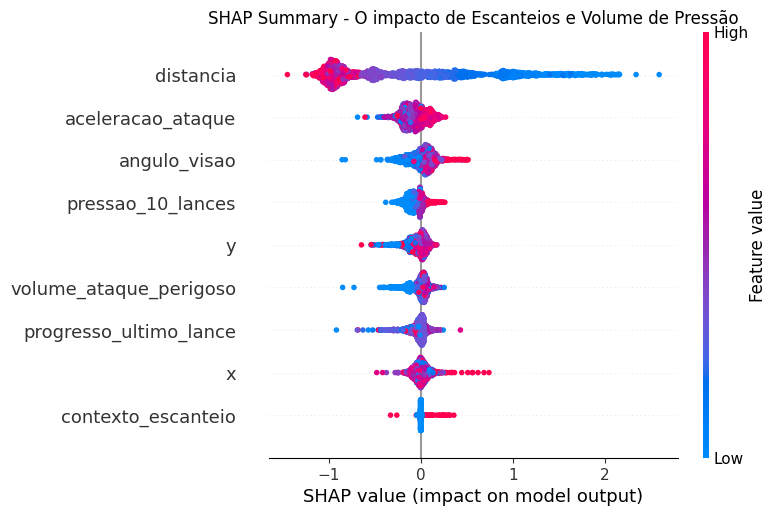


💾 Modelo Híbrido salvo! Pronto para o Backend.


In [16]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
import numpy as np
import shap
import matplotlib.pyplot as plt

print("🚀 Iniciando PIPELINE PROFISSIONAL (Híbrido Micro+Macro)...")

PATH = "Data/atacks_defense/ataque_oraculo.parquet"
df_ml = pd.read_parquet(PATH)

# FEATURES ATUALIZADAS
features = [
    'x', 'y', 'distancia', 'angulo_visao',
    'pressao_10_lances', 'aceleracao_ataque', 'progresso_ultimo_lance',
    'contexto_escanteio', 'volume_ataque_perigoso'
]

X = df_ml[features].values
y = df_ml['iminencia_gol'].values
groups = df_ml['match_id'].values

pos_weight = (len(y) - y.sum()) / y.sum()

gkf = GroupKFold(n_splits=5)
auc_scores, brier_scores, models = [], [], []

print(f"🔄 Validando Oráculo em {len(np.unique(groups))} partidas...")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model = xgb.XGBClassifier(
        n_estimators=1000, # Aumentamos um pouco para lidar com mais features
        max_depth=8,
        learning_rate=0.03,
        scale_pos_weight=pos_weight,
        tree_method='hist',
        eval_metric='auc',
        early_stopping_rounds=60,
        random_state=42
    )
    
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    probas = model.predict_proba(X_test)[:, 1]
    auc_scores.append(roc_auc_score(y_test, probas))
    brier_scores.append(brier_score_loss(y_test, probas))
    models.append(model)
    
    print(f"Fold {fold} → AUC: {auc_scores[-1]:.4f}")

print("\n" + "="*50)
print(f"✅ AUC MÉDIO FINAL: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print("="*50)

# ====================== SHAP: O QUE MUDA COM ESCANTEIOS? ======================
best_model = models[-1]
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test[:2000])

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test[:2000], feature_names=features, show=False)
plt.title("SHAP Summary - O impacto de Escanteios e Volume de Pressão")
plt.show()

# ====================== SALVAMENTO ======================
best_model.save_model("oraculo_iminencia_HIBRIDO_v1.json")
print("\n💾 Modelo Híbrido salvo! Pronto para o Backend.")

In [12]:
def criar_contexto_tatico(event_data, probabilidade):
    # Transforma números em palavras
    zona = "dentro da área" if event_data['x'] > 102 else "entrada da área"
    perigo = "CRÍTICO" if probabilidade > 0.85 else "ALTO"
    
    contexto = f"""
    Contexto do Jogo:
    - Jogador: {event_data['player_name']}
    - Ação: {event_data['type_name']}
    - Localização: {zona} (x={event_data['x']:.1f})
    - Pressão: {'Sim' if event_data['under_pressure'] else 'Não'}
    - Probabilidade de Chute Imminente: {probabilidade:.2%}
    - Nível de Perigo: {perigo}
    """
    return contexto

import requests

def gerar_alerta_hf(contexto_tatico, HF_TOKEN):
    API_URL = "https://api-inference.huggingface.co/models/mistralai/Mistral-7B-Instruct-v0.2"
    headers = {"Authorization": f"Bearer {HF_TOKEN}"}
    
    prompt = f"<s>[INST] Você é um comentarista de futebol estilo 'Narrador de rádio'. Baseado nestes dados, gere um alerta urgente de 1 frase para o dashboard: {contexto_tatico} [/INST]"
    
    response = requests.post(API_URL, headers=headers, json={"inputs": prompt})
    return response.json()[0]['generated_text']

BETAPI